In [ ]:
# 1._ Importar librerías

In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline

from src.preprocessing import build_preprocessing_pipeline



In [ ]:
# cargar dataset

In [3]:
df = pd.read_csv("../../data/raw/dataset_practica_final.csv")
df.head()


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
# 2._ Preparar datos y preprocesamiento

In [4]:
# Separar variables
X = df.drop("is_canceled", axis=1)
y = df["is_canceled"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Crear preprocesador real del proyecto
preprocessor = build_preprocessing_pipeline(df)


In [ ]:
# 3._ Entrenar los 5 modelos (solo para evaluación visual)

In [5]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "Neural Network": MLPClassifier(max_iter=300)
}

modelos_entrenados = {}

for nombre, modelo in modelos.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", modelo)
    ])
    clf.fit(X_train, y_train)
    modelos_entrenados[nombre] = clf

print("Modelos entrenados correctamente.")



Modelos entrenados correctamente.


In [ ]:
# 4._ Curva ROC comparativa

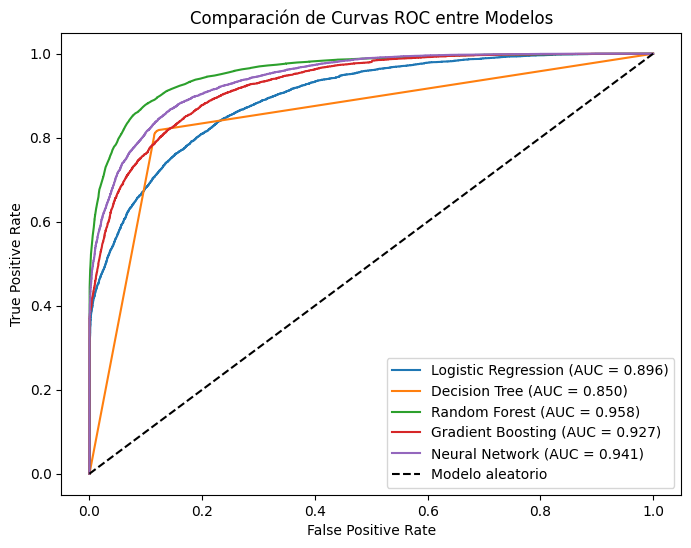

In [6]:
plt.figure(figsize=(8,6))

for nombre, modelo in modelos_entrenados.items():
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{nombre} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], "k--", label="Modelo aleatorio")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación de Curvas ROC entre Modelos")
plt.legend()
plt.savefig("../../outputs/roc_comparativa.png", dpi=300, bbox_inches="tight")

plt.show()




In [ ]:
# 5._ Matriz de confusión del mejor modelo (Random Forest suele ser el mejor)

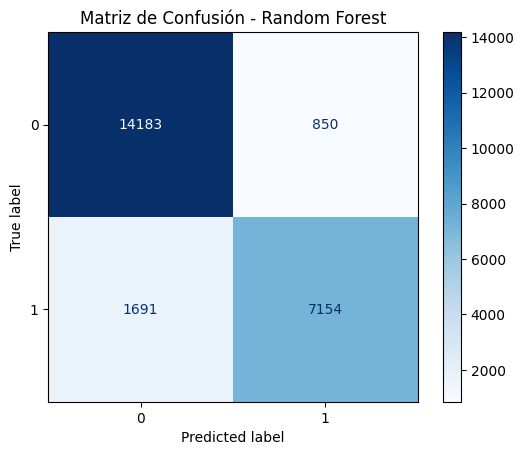

In [7]:
mejor_modelo = modelos_entrenados["Random Forest"]

y_pred = mejor_modelo.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Matriz de Confusión - Random Forest")
plt.savefig("../../outputs/matriz_confusion.png", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# 6._ Importancia de variables

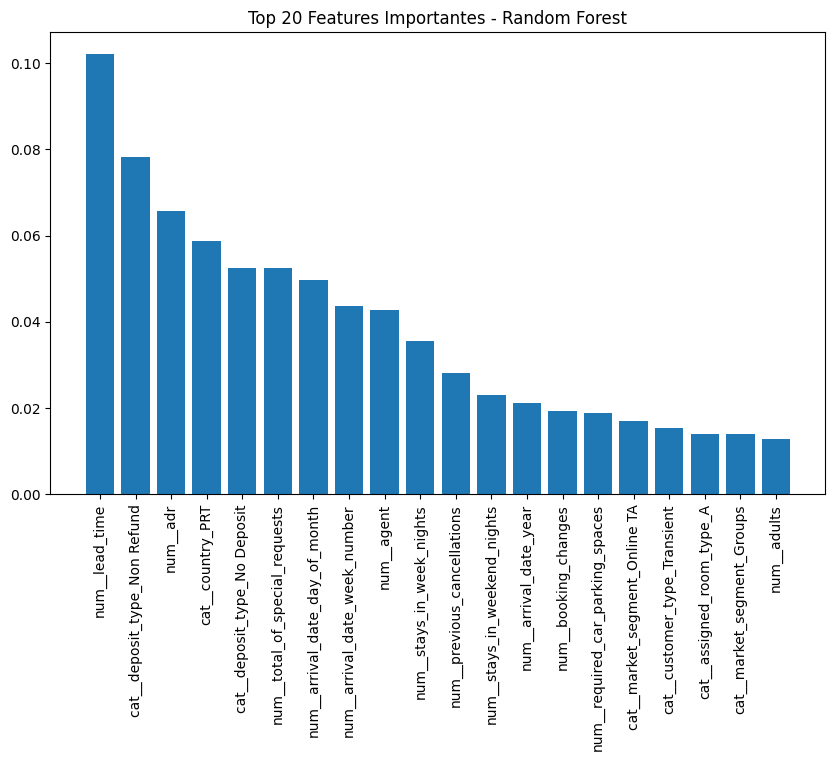

In [8]:
import numpy as np

modelo_rf = modelos_entrenados["Random Forest"]

# Obtener nombres de columnas tras el preprocesamiento
feature_names = modelo_rf.named_steps["preprocessor"].get_feature_names_out()

importances = modelo_rf.named_steps["model"].feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(20), importances[indices][:20])
plt.xticks(range(20), feature_names[indices][:20], rotation=90)
plt.title("Top 20 Features Importantes - Random Forest")
plt.savefig("../../outputs/feature_importances.png", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# 7._ Importancia de varibles solo en caso de que el modelo lo soporte, como Random Forest o Gradient Boosting nada mas.

In [9]:
import joblib
import numpy as np
import pandas as pd

# Cargar el mejor modelo entrenado por el pipeline
best_model = joblib.load(os.path.join(project_root, "models", "best_model.pkl"))

# Extraer modelo y preprocesador
model = best_model.named_steps["model"]
preprocessor = best_model.named_steps["preprocessor"]

# Obtener nombres de columnas numéricas
num_features = preprocessor.transformers_[0][2]

# Obtener nombres de columnas categóricas codificadas
cat_features = preprocessor.transformers_[1][2]
encoded_cols = preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(cat_features)

# Unir todas las columnas finales
all_features = list(num_features) + list(encoded_cols)

# Importancias del modelo (solo funciona si es árbol, RF, GB, etc.)
importances = model.feature_importances_

# Crear dataframe ordenado
feat_imp = pd.DataFrame({
    "feature": all_features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

feat_imp.head(20)



,feature,importance
0,lead_time,0.106192
15,adr,0.066144
244,deposit_type_No Deposit,0.059275
167,country_PRT,0.059172
245,deposit_type_Non Refund,0.057828
17,total_of_special_requests,0.054164
3,arrival_date_day_of_month,0.050064
2,arrival_date_week_number,0.044599
13,agent,0.041796
5,stays_in_week_nights,0.035427


In [ ]:
# Conclusiones del EDA inicial:
# El análisis de importancia de variables muestra que los factores más influyentes en la cancelación de reservas son el tiempo de antelación (lead_time), el tipo de depósito, el precio por noche (adr), el país de origen y el número de solicitudes especiales. Estos resultados son coherentes con el comportamiento real de los clientes en el sector hotelero, donde las reservas con mayor antelación, sin depósito o con precios elevados presentan mayor probabilidad de cancelación.